# Training Russian Language Models: Pretraining and Instruction Tuning

This notebook implements an end-to-end LLM training pipeline in two stages. First, a 154M-parameter Qwen2-style decoder-only model is pretrained from scratch on a curated corpus of Russian literature. Second, the base `Qwen/Qwen2.5-0.5B` model is instruction-tuned on a Russian conversational dataset with supervised fine-tuning (SFT).

The notebook preserves the outputs of the original experiments so that the preprocessing statistics, training curves, evaluation metrics, and generations can be inspected without rerunning the multi-hour training jobs.

## 1. Environment and reproducibility

All random number generators use a fixed seed. Training automatically selects BF16 or FP16 based on GPU support, and checkpoints are stored under the local `artifacts` directory.

In [1]:
import json
import math
import random
import re
import unicodedata
from collections import Counter
from pathlib import Path

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from datasets import Dataset, DatasetDict, load_from_disk
from tokenizers import Tokenizer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.models import BPE
from tokenizers.normalizers import NFKC
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.processors import TemplateProcessing
from tokenizers.trainers import BpeTrainer
from transformers import (
    DataCollatorForLanguageModeling,
    Qwen2Config,
    Qwen2ForCausalLM,
    PreTrainedTokenizerFast,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

PROJECT_NAME = "russian-llm-training-pipeline"
working_directory = Path.cwd().resolve()
project_candidates = [
    working_directory,
    working_directory / PROJECT_NAME,
    working_directory / "nlp_sp2" / PROJECT_NAME,
]
PROJECT_DIR = next(
    (path for path in project_candidates if path.name == PROJECT_NAME and path.exists()),
    working_directory,
)

# Prefer a self-contained corpus, then fall back to the original course-project data.
corpus_candidates = [
    PROJECT_DIR / "data" / "corpus",
    PROJECT_DIR.parent / "project" / "data" / "corpus",
]
CORPUS_DIR = next((path for path in corpus_candidates if path.exists()), corpus_candidates[0])
if not CORPUS_DIR.exists():
    raise FileNotFoundError(
        "Corpus not found. Place Russian literature .txt files under data/corpus."
    )
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
TOKENIZER_DIR = ARTIFACTS_DIR / "tokenizer_bpe_3000"
DATASET_DIR = ARTIFACTS_DIR / "dataset_ctx512"
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
FINAL_MODEL_DIR = ARTIFACTS_DIR / "final_model"
for directory in [ARTIFACTS_DIR, TOKENIZER_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("GPU memory, GB:", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))

PyTorch: 2.12.0.dev20260408+cu128
Transformers: 5.14.0
Datasets: 5.0.0
CUDA доступна: True
Устройство: NVIDIA GeForce RTX 5080 Laptop GPU
Память GPU, ГБ: 15.9


## 2. Loading and inspecting the literature corpus

Every `.txt` file is treated as a separate literary work. The loader supports common encodings used for Russian texts and reports the number of documents, total character count, and detected encodings.

In [2]:
def read_text_safely(path: Path) -> tuple[str, str]:
    '''Read a text file by trying common Russian-text encodings.'''
    for encoding in ("utf-8-sig", "utf-8", "cp1251"):
        try:
            return path.read_text(encoding=encoding), encoding
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("unknown", b"", 0, 1, f"Could not decode {path}")


text_files = sorted(CORPUS_DIR.rglob("*.txt"))

raw_documents = []
encoding_counter = Counter()
for path in text_files:
    text, encoding = read_text_safely(path)
    raw_documents.append({"source": path.name, "text": text})
    encoding_counter[encoding] += 1

total_characters = sum(len(item["text"]) for item in raw_documents)
print(f"Literary works found: {len(raw_documents):,}")
print(f"Total size: {total_characters:,} characters")
print("Encodings:", dict(encoding_counter))
print("Corpus preview:\n")
print(raw_documents[0]["text"][:700])

Найдено произведений: 108
Общий объём: 45,348,575 символов
Кодировки: {'utf-8-sig': 108}
Пример начала корпуса:


                                 Посвящается Любови Евгеньевне Белозерской



                             Пошел мелкий снег и вдруг  повалил  хлопьями.
                          Ветер завыл; сделалась метель. В одно  мгновение
                          темное  небо  смешалось  с  снежным  морем.  Все
                          исчезло.
                             - Ну, барин, - закричал ямщик, - беда: буран!
                                                       "Капитанская дочка"

                             И судимы были мертвые по написанному в книгах
                          сообразно с делами своими...



ЧАСТЬ ПЕРВАЯ



1


   Велик был год и страшен год по рождестве Христовом 191


## 3. Cleaning, normalization, and deduplication

The preprocessing pipeline:

1. applies NFKC Unicode normalization and standardizes quotes, dashes, and non-breaking spaces;
2. removes control characters and redundant whitespace;
3. normalizes repeated punctuation (`!!!` → `!`, `????` → `?`, long dot sequences → `…`);
4. splits documents into sentences;
5. removes sentences containing letters outside the Russian Cyrillic alphabet;
6. removes exact duplicates while ignoring case and whitespace differences.

In [3]:
SENTENCE_BOUNDARY_RE = re.compile(r"(?<=[.!?…])\s+")
SPACE_RE = re.compile(r"[ \t\f\v]+")
CONTROL_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")


def is_russian_cyrillic_letter(char: str) -> bool:
    '''Check whether a character belongs to the Russian Cyrillic alphabet.'''
    return char in "Ёё" or "А" <= char <= "я"


def contains_non_cyrillic_letters(text: str) -> bool:
    '''Detect letters from other alphabets; digits and punctuation are allowed.'''
    return any(char.isalpha() and not is_russian_cyrillic_letter(char) for char in text)


def normalize_text(text: str) -> str:
    '''Normalize Unicode, whitespace, quotation marks, dashes, and repeated punctuation.'''
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u00a0", " ").replace("\ufeff", "")
    text = text.translate(str.maketrans({
        "«": '"', "»": '"', "„": '"', "“": '"', "”": '"',
        "–": "—", "−": "—",
    }))
    text = CONTROL_RE.sub(" ", text)
    text = re.sub(r"\r\n?", "\n", text)
    text = re.sub(r"\.{3,}", "…", text)
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)
    text = re.sub(r"(?:!\?)+|(?:\?!)+", "?!", text)
    text = re.sub(r"[-—]{3,}", "—", text)
    text = SPACE_RE.sub(" ", text)
    text = re.sub(r" *\n+ *", "\n", text)
    return text.strip()


def split_into_sentences(text: str) -> list[str]:
    '''Split text into sentences and clean their boundaries.'''
    text = re.sub(r"\n+", " ", normalize_text(text))
    candidates = SENTENCE_BOUNDARY_RE.split(text)
    result = []
    for sentence in candidates:
        sentence = SPACE_RE.sub(" ", sentence).strip(" \t—-")
        # Single-character headings and chapter numbers provide no useful language context.
        if len(sentence) >= 2:
            result.append(sentence)
    return result


seen_sentences = set()
clean_documents = []
statistics = Counter()

for document in raw_documents:
    accepted = []
    for sentence in split_into_sentences(document["text"]):
        statistics["sentences before filtering"] += 1
        if contains_non_cyrillic_letters(sentence):
            statistics["removed: non-Cyrillic letters"] += 1
            continue
        key = SPACE_RE.sub(" ", sentence).strip().lower()
        if key in seen_sentences:
            statistics["removed: duplicates"] += 1
            continue
        seen_sentences.add(key)
        accepted.append(sentence)
    if accepted:
        clean_documents.append({
            "source": document["source"],
            "text": " ".join(accepted),
            "n_sentences": len(accepted),
        })

statistics["sentences retained"] = sum(item["n_sentences"] for item in clean_documents)
statistics["documents retained"] = len(clean_documents)
print(json.dumps(dict(statistics), ensure_ascii=False, indent=2))
print("\nCleaned-text preview:\n")
print(clean_documents[0]["text"][:900])

{
  "всего предложений": 549138,
  "удалено дубликатов": 38418,
  "удалено из-за некриллических букв": 21540,
  "оставлено предложений": 489180,
  "оставлено произведений": 107
}

Пример очищенного текста:

Посвящается Любови Евгеньевне Белозерской Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное небо смешалось с снежным морем. Все исчезло. Ну, барин, - закричал ямщик, - беда: буран! "Капитанская дочка" И судимы были мертвые по написанному в книгах сообразно с делами своими… ЧАСТЬ ПЕРВАЯ 1 Велик был год и страшен год по рождестве Христовом 1918, от начала же революции второй. Был он обилен летом солнцем, а зимою снегом, и особенно высоко в небе стояли две звезды: звезда пастушеская - вечерняя Венера и красный, дрожащий Марс. Но дни и в мирные и в кровавые годы летят как стрела, и молодые Турбины не заметили, как в крепком морозе наступил белый, мохнатый декабрь. О, елочный дед наш, сверкающий снегом и счастьем! Мама, светлая королева, г

Символов после очистки: 40,159,251
Медиана символов на произведение: 275,102


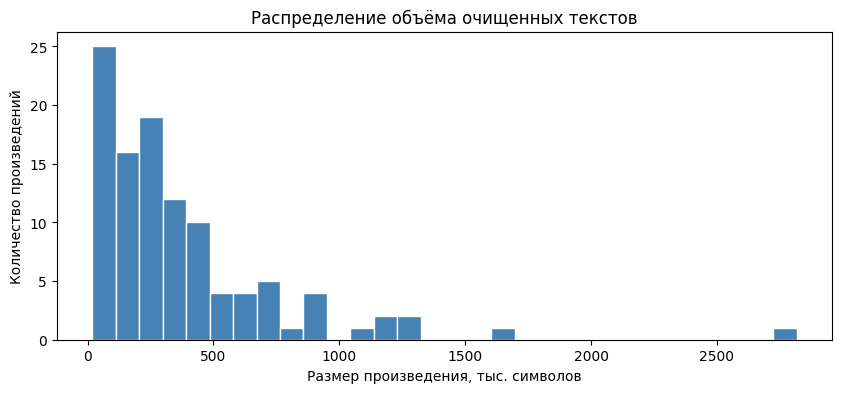

In [4]:
# Inspect the size distribution of the cleaned documents.
lengths = np.array([len(item["text"]) for item in clean_documents])
print("Characters after cleaning:", f"{lengths.sum():,}")
print("Median characters per work:", f"{int(np.median(lengths)):,}")

plt.figure(figsize=(10, 4))
plt.hist(lengths / 1_000, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Work size, thousand characters")
plt.ylabel("Number of works")
plt.title("Distribution of cleaned document sizes")
plt.show()

## 4. Document-level train/validation split

The split is performed by literary work rather than by random text chunk. This prevents adjacent passages from the same book from appearing in both training and validation data and provides a more realistic estimate of generalization to held-out works.

In [5]:
documents_dataset = Dataset.from_list(clean_documents)
document_splits = documents_dataset.train_test_split(test_size=0.05, seed=SEED)
document_splits = DatasetDict({
    "train": document_splits["train"],
    "validation": document_splits["test"],
})

print(document_splits)
print("\nValidation works:")
for source in document_splits["validation"]["source"]:
    print("-", source)

DatasetDict({
    train: Dataset({
        features: ['source', 'text', 'n_sentences'],
        num_rows: 101
    })
    validation: Dataset({
        features: ['source', 'text', 'n_sentences'],
        num_rows: 6
    })
})

Валидационные произведения:
- Nabokov_Pnin_1957_Barabtarlo.txt
- Durova_IgraSudby.txt
- Tolstoi_VoynaIMir2.txt
- Gogol_Mertvye.txt
- Nabokov_Veschi_1972_Ilin.txt
- Bulgakov_BelayaGvardiya.txt


## 5. Training a custom BPE tokenizer

The tokenizer is trained only on the training split. It uses byte-level BPE with a vocabulary of 3,000 tokens and five special tokens. A compact vocabulary is appropriate because the corpus covers a narrow language and literary domain.

In [6]:
VOCAB_SIZE = 3_000
SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>", "<mask>"]

backend_tokenizer = Tokenizer(BPE(unk_token="<unk>"))
backend_tokenizer.normalizer = NFKC()
backend_tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
backend_tokenizer.decoder = ByteLevelDecoder()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=2,
    special_tokens=SPECIAL_TOKENS,
    show_progress=True,
)


def training_text_iterator(batch_size: int = 16):
    '''Yield texts in small batches without copying the full corpus.'''
    texts = document_splits["train"]["text"]
    for start in range(0, len(texts), batch_size):
        yield texts[start:start + batch_size]


backend_tokenizer.train_from_iterator(
    training_text_iterator(),
    trainer=trainer,
    length=len(document_splits["train"]),
)
backend_tokenizer.post_processor = TemplateProcessing(
    single="<bos> $A",
    pair="<bos> $A <eos> $B",
    special_tokens=[
        ("<bos>", backend_tokenizer.token_to_id("<bos>")),
        ("<eos>", backend_tokenizer.token_to_id("<eos>")),
    ],
)
backend_tokenizer.save(str(TOKENIZER_DIR / "tokenizer.json"))

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=backend_tokenizer,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
    model_max_length=512,
)
tokenizer.save_pretrained(TOKENIZER_DIR)

print("Actual vocabulary size:", len(tokenizer))
sample = "Война не любезность, а самое гадкое дело."
sample_ids = tokenizer.encode(sample, add_special_tokens=False)
print("Tokens:", tokenizer.convert_ids_to_tokens(sample_ids))
print("Decoded text:", tokenizer.decode(sample_ids))

Фактический размер словаря: 3000
Токены: ['ÐĴ', 'Ð¾Ð¹', 'Ð½Ð°', 'ĠÐ½Ðµ', 'ĠÐ»ÑİÐ±', 'ÐµÐ·', 'Ð½Ð¾ÑģÑĤÑĮ', ',', 'ĠÐ°', 'ĠÑģÐ°Ð¼Ð¾Ðµ', 'ĠÐ³', 'Ð°Ð´', 'ÐºÐ¾Ðµ', 'ĠÐ´ÐµÐ»Ð¾', '.']
Обратное декодирование: Война не любезность, а самое гадкое дело.


In [7]:
# Measure segmentation quality using the unknown-token rate and tokens per word.
probe_texts = list(document_splits["validation"]["text"])
probe_encodings = tokenizer(
    probe_texts,
    add_special_tokens=False,
    verbose=False,
)["input_ids"]
probe_ids = [token_id for row in probe_encodings for token_id in row]
probe_words = sum(len(text.split()) for text in probe_texts)
unknown_share = sum(token_id == tokenizer.unk_token_id for token_id in probe_ids) / max(len(probe_ids), 1)

print(f"Validation tokens: {len(probe_ids):,}")
print(f"Tokens per word: {len(probe_ids) / max(probe_words, 1):.3f}")
print(f"<unk> rate: {unknown_share:.6%}")

Токенов в валидационной части: 731,564
Токенов на слово: 2.155
Доля <unk>: 0.000000%


## 6. Tokenization and packing into a 512-token context

Every language-modeling example contains exactly 512 tokens:

`<bos>` + 510 text tokens + `<eos>`.

The final partial block of each work is padded with `<pad>`, and padded positions receive a label of `-100` so they do not contribute to the loss. Document boundaries are never mixed.

In [8]:
CONTEXT_LENGTH = 512
CONTENT_LENGTH = CONTEXT_LENGTH - 2


def tokenize_documents(batch):
    '''Tokenize documents without automatically adding special tokens.'''
    return tokenizer(
        batch["text"],
        add_special_tokens=False,
        truncation=False,
        verbose=False,
    )


tokenized_documents = document_splits.map(
    tokenize_documents,
    batched=True,
    remove_columns=document_splits["train"].column_names,
    desc="Tokenizing documents",
)


def pack_documents(batch):
    '''Split each work into independent context blocks.'''
    packed = {"input_ids": [], "attention_mask": [], "labels": []}
    for document_ids in batch["input_ids"]:
        for start in range(0, len(document_ids), CONTENT_LENGTH):
            content = document_ids[start:start + CONTENT_LENGTH]
            input_ids = [tokenizer.bos_token_id, *content, tokenizer.eos_token_id]
            attention_mask = [1] * len(input_ids)
            padding = CONTEXT_LENGTH - len(input_ids)
            if padding:
                input_ids.extend([tokenizer.pad_token_id] * padding)
                attention_mask.extend([0] * padding)
            labels = [token_id if mask else -100
                      for token_id, mask in zip(input_ids, attention_mask)]
            packed["input_ids"].append(input_ids)
            packed["attention_mask"].append(attention_mask)
            packed["labels"].append(labels)
    return packed


lm_dataset = tokenized_documents.map(
    pack_documents,
    batched=True,
    remove_columns=tokenized_documents["train"].column_names,
    desc="Packing 512-token blocks",
)
lm_dataset.set_format(type="torch")

print(lm_dataset)
print("First block length:", len(lm_dataset["train"][0]["input_ids"]))
print("First token is <bos>:", lm_dataset["train"][0]["input_ids"][0].item() == tokenizer.bos_token_id)
train_token_count = sum(int(mask.sum()) for mask in lm_dataset["train"]["attention_mask"])
print("Training-token count:", f"{train_token_count:,}")

Токенизация произведений:   0%|          | 0/101 [00:00<?, ? examples/s]

Токенизация произведений:   0%|          | 0/6 [00:00<?, ? examples/s]

Упаковка блоков по 512 токенов:   0%|          | 0/101 [00:00<?, ? examples/s]

Упаковка блоков по 512 токенов:   0%|          | 0/6 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 24935
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1438
    })
})
Длина первого блока: 512
Первый токен — <bos>: True
Число обучающих токенов: 12,739,063


In [9]:
# Save the prepared Dataset to make repeated training runs faster.
if DATASET_DIR.exists():
    print("The dataset directory already exists; the current dataset remains in memory.")
else:
    lm_dataset.save_to_disk(DATASET_DIR)
    print("Dataset saved to", DATASET_DIR)

Каталог датасета уже существует; текущий датасет оставлен в памяти.


## 7. Initializing a ~150M-parameter model

The model uses the decoder-only Qwen2 architecture with grouped-query attention. A hidden size of 1,024, 16 layers, and an intermediate size of 2,048 produce 154.1M trainable parameters. The model is initialized from scratch without pretrained weights.

In [10]:
model_config = Qwen2Config(
    vocab_size=len(tokenizer),
    hidden_size=1024,
    intermediate_size=2048,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,
    max_position_embeddings=CONTEXT_LENGTH,
    rms_norm_eps=1e-5,
    attention_dropout=0.0,
    hidden_act="silu",
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    tie_word_embeddings=True,
    use_cache=False,
)

model = Qwen2ForCausalLM(model_config)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Total parameters: {parameter_count:,} ({parameter_count / 1e6:.1f}M)")
print(f"Trainable parameters: {trainable_count:,}")

Всего параметров: 154,133,504 (154.1M)
Обучаемых параметров: 154,133,504


## 8. Qualitative validation callback

In addition to validation loss and perplexity, the callback generates continuations for three fixed Russian prompts after each evaluation. This makes it possible to track improvements in fluency and literary style during training.

In [11]:
test_prompts = [
    "Все мысли, которые имеют огромные последствия",
    "Сила войска зависит от его духа",
    "Мысль о том, что он принес страдания",
    "Человек сознает себя свободным",
    "Что бы ни случилось, я всегда буду",
    "Любовь мешает смерти",
    "Нет, жизнь не кончена",
    "Всякая мысль, даже самая простая",
    "Война не любезность, а самое гадкое дело",
    "Чтобы жить честно",
]


@torch.inference_mode()
def generate_continuations(model, prompts, max_new_tokens=60, do_sample=False):
    '''Generate continuations and return them together with the original prompts.'''
    was_training = model.training
    model.eval()
    device = next(model.parameters()).device
    old_use_cache = model.config.use_cache
    model.config.use_cache = True
    results = []
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(device)
        generation_kwargs = {
            "max_new_tokens": max_new_tokens,
            "repetition_penalty": 1.15,
            "no_repeat_ngram_size": 3,
            "pad_token_id": tokenizer.pad_token_id,
            "eos_token_id": tokenizer.eos_token_id,
        }
        if do_sample:
            generation_kwargs.update({"do_sample": True, "temperature": 0.8, "top_p": 0.92})
        else:
            generation_kwargs.update({"do_sample": False})
        output = model.generate(**inputs, **generation_kwargs)
        results.append(tokenizer.decode(output[0], skip_special_tokens=True))
    model.config.use_cache = old_use_cache
    if was_training:
        model.train()
    return results


class PromptGenerationCallback(TrainerCallback):
    '''Print sample continuations after each validation run.'''

    def on_evaluate(self, args, state, control, model=None, metrics=None, **kwargs):
        if not state.is_world_process_zero or model is None:
            return control
        print("\nQualitative evaluation after step", state.global_step)
        if metrics and "eval_loss" in metrics:
            perplexity = math.exp(min(metrics["eval_loss"], 20))
            print(f"Validation loss: {metrics['eval_loss']:.4f}; perplexity: {perplexity:.2f}")
        for result in generate_continuations(model, test_prompts[:3], max_new_tokens=40):
            print("•", result)
        return control

## 9. Configuring and running `Trainer`

The physical batch size is 2 and gradients are accumulated for 32 micro-batches, resulting in an effective batch size of **64 sequences**. `weight_decay=0.1` regularizes the model, while cosine decay and warmup stabilize training from random initialization.

In [14]:
PER_DEVICE_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 32
EFFECTIVE_BATCH_SIZE = PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
NUM_EPOCHS = 3


training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=3e-4,
    weight_decay=0.1,
    warmup_steps=12,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    tf32=torch.cuda.is_available(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    eval_strategy="steps",
    eval_steps=250,
    logging_strategy="steps",
    logging_steps=25,
    logging_first_step=True,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_dataset["train"],
    eval_dataset=lm_dataset["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[PromptGenerationCallback()],
)

steps_per_epoch = math.ceil(len(lm_dataset["train"]) / EFFECTIVE_BATCH_SIZE)
print("Effective batch size:", EFFECTIVE_BATCH_SIZE)
print("Expected optimizer steps per epoch:", steps_per_epoch)

Эффективный batch size: 64
Ожидаемое число шагов оптимизатора за эпоху: 390


In [15]:
# This cell runs the long training job and resumes the latest incomplete run.
checkpoints = sorted(
    CHECKPOINT_DIR.glob("checkpoint-*"),
    key=lambda path: int(path.name.split("-")[-1]),
)
resume_checkpoint = str(checkpoints[-1]) if checkpoints else None
print("Resuming from checkpoint:", resume_checkpoint or "training from scratch")

train_result = trainer.train(resume_from_checkpoint=resume_checkpoint)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()
print("Final model saved to", FINAL_MODEL_DIR)

Продолжение с чекпойнта: c:\Users\Mikhail\projects\deep_learn_prac\nlp_sp2\project\artifacts\checkpoints\checkpoint-390


[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Step,Training Loss,Validation Loss
500,3.976033,4.061561
750,3.623732,3.742136
1000,3.390802,3.633338
1170,3.374632,3.619869



Качественная проверка после шага 500
Ошибка валидации: 4.0616; перплексия: 58.06
• Все мысли, которые имеют огромные последствия, и в то же время, как будто бы не было. Но все это было так же, что он был в том, что она была в нем, и, когда он, может быть,
• Сила войска зависит от его духа. И он, как бы не в силах был, и в то же время, когда он был в нем, и он был на него, и ему было бы не только потому, что
• Мысль о том, что он принес страдания и не мог бы ему. Он был в сущности, но в то же время, как он, когда он был в его душе, и в то время, что в нем было так,


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Качественная проверка после шага 1170
Ошибка валидации: 3.6199; перплексия: 37.33
• Все мысли, которые имеют огромные последствия. Вдруг он был влюблен в нее, и она была в его душе. Она была очень хороша, но не могла быть счастливой, какою она была так же, как
• Сила войска зависит от его духа. Вдруг она была влюблена в нее, но не могла понять ее, что она будет делать с нею. Она знала, что это было для нее, и ей казалось, что он
• Мысль о том, что он принес страдания. Вдруг он снял очки и, не глядя на него, сказал: -- Неужели вы думаете, что я могу сказать? Я не знаю, что это значит. Он был


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Итоговая модель сохранена в c:\Users\Mikhail\projects\deep_learn_prac\nlp_sp2\project\artifacts\final_model


## 10. Pretraining metrics and final generation

Perplexity is calculated from the held-out loss. The final model then generates continuations for all ten evaluation prompts using controlled sampling.

In [16]:
eval_metrics = trainer.evaluate()
eval_metrics["perplexity"] = math.exp(min(eval_metrics["eval_loss"], 20))
print(json.dumps(eval_metrics, ensure_ascii=False, indent=2))


Качественная проверка после шага 1170
Ошибка валидации: 3.6199; перплексия: 37.33
• Все мысли, которые имеют огромные последствия. Вдруг он был влюблен в нее, и она была в его душе. Она была очень хороша, но не могла быть счастливой, какою она была так же, как
• Сила войска зависит от его духа. Вдруг она была влюблена в нее, но не могла понять ее, что она будет делать с нею. Она знала, что это было для нее, и ей казалось, что он
• Мысль о том, что он принес страдания. Вдруг он снял очки и, не глядя на него, сказал: -- Неужели вы думаете, что я могу сказать? Я не знаю, что это значит. Он был


Training Loss,Validation Loss,Step
3.374632,3.619869,1170


{
  "eval_loss": 3.6198689937591553,
  "perplexity": 37.33267668804254
}


In [17]:
# Reset the seed to make the generated samples reproducible.
set_seed(SEED)
final_generations = generate_continuations(
    trainer.model,
    test_prompts,
    max_new_tokens=100,
    do_sample=True,
)

for number, (prompt, result) in enumerate(zip(test_prompts, final_generations), start=1):
    continuation = result[len(prompt):].strip() if result.startswith(prompt) else result
    print(f"{number}. PROMPT: {prompt}")
    print("   CONTINUATION:", continuation)
    print()

1. ПРОМПТ: Все мысли, которые имеют огромные последствия
   ПРОДОЛЖЕНИЕ: или коврами. Как это было для того, чтоб спокоть, в каком-то мраке и безобразиях. Испытанный, безнадежно оглянулся и с улыбкой сказал: - Мы можем жить вместе со всеми его женою; если бы мы еще не могли сделать вас, потому что я по себе в доме не видел. Несмотря на то, что все они все-таки расстроены, и она

2. ПРОМПТ: Сила войска зависит от его духа
   ПРОДОЛЖЕНИЕ: в этом случае и обеспокоил. Он был виноват и не мог понять его, но она даже была счастлива. В это время в первое время старого графа и Кити, которого он видел и не могла бы сказать в том, что у него есть. Совершенно спокойна была Лиза. Она стояла на корзине с кушанья, которую она так любила, как и в Петербурге, и только по-прежнему сид

3. ПРОМПТ: Мысль о том, что он принес страдания
   ПРОДОЛЖЕНИЕ: , когда у нас было на земле. Но в душе этого не случилось, что я должен был с ним сделать. Видишь ли, я хотел вас сказать, и мне хотелось еще видеться с вам

## Pretraining findings

The model learned the local structure, vocabulary, punctuation, and basic grammar of Russian literary prose. Validation loss reached **3.6199**, corresponding to a perplexity of **37.33**. The generations resemble literary passages at the sentence level, but their long-range semantic coherence remains limited. This is expected because the 154M-parameter model saw only about 38M tokens over three epochs.

# Part 2. Post-training with supervised fine-tuning

The second stage turns a pretrained base model into a Russian-language assistant. `Qwen/Qwen2.5-0.5B` is fine-tuned on `d0rj/alpaca-cleaned-ru` in a conversational prompt-completion format. The same four questions are generated before and after SFT to provide a direct qualitative comparison.

In [18]:
import importlib.util
import subprocess
import sys

import gc
import trl
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

# Release the pretraining model and optimizer before loading Qwen2.5-0.5B.
for variable_name in ("trainer", "model"):
    if variable_name in globals():
        del globals()[variable_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_MODEL_NAME = "Qwen/Qwen2.5-0.5B"
SFT_ROOT_DIR = ARTIFACTS_DIR / "sft"
SFT_CACHE_DIR = SFT_ROOT_DIR / "hf_cache"
SFT_CHECKPOINT_DIR = SFT_ROOT_DIR / "checkpoints"
SFT_FINAL_MODEL_DIR = SFT_ROOT_DIR / "final_model"
for directory in [SFT_ROOT_DIR, SFT_CACHE_DIR, SFT_CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("TRL version:", trl.__version__)
print("Base model:", SFT_MODEL_NAME)

Версия TRL: 1.8.0
Базовая модель: Qwen/Qwen2.5-0.5B


## 11. Baseline quality before SFT

The base model is evaluated with deterministic greedy decoding. Without instruction tuning, it frequently mixes languages, emits malformed dialogue markers, and fails to maintain a useful answer structure.

In [19]:
evaluation_questions_ru = [
    "сколько планет в нашей солнечной системе?",
    "расскажи стих",
    "когда собирать крыжовник?",
    "Как быстро выучить новый язык?",
]

SFT_SYSTEM_PROMPT = (
    "Ты полезный русскоязычный ассистент. "
    "Отвечай на вопрос ясно, содержательно и на русском языке."
)

sft_tokenizer = AutoTokenizer.from_pretrained(
    SFT_MODEL_NAME,
    cache_dir=SFT_CACHE_DIR,
)
if sft_tokenizer.pad_token_id is None:
    sft_tokenizer.pad_token = sft_tokenizer.eos_token
sft_tokenizer.padding_side = "right"

sft_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_NAME,
    cache_dir=SFT_CACHE_DIR,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    attn_implementation="sdpa",
)
if torch.cuda.is_available():
    sft_model = sft_model.to("cuda")


@torch.inference_mode()
def generate_sft_answers(model, questions, max_new_tokens=160):
    '''Generate Qwen responses in chat format and return assistant messages only.'''
    model.eval()
    answers = []
    for question in questions:
        messages = [
            {"role": "system", "content": SFT_SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ]
        encoded = sft_tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        ).to(model.device)
        prompt_length = encoded["input_ids"].shape[1]
        output_ids = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            pad_token_id=sft_tokenizer.pad_token_id,
            eos_token_id=sft_tokenizer.eos_token_id,
        )
        answer_ids = output_ids[0, prompt_length:]
        answers.append(sft_tokenizer.decode(answer_ids, skip_special_tokens=True).strip())
    return answers


base_answers = generate_sft_answers(sft_model, evaluation_questions_ru)
print("=== Base model before SFT ===\n")
for number, (question, answer) in enumerate(zip(evaluation_questions_ru, base_answers), start=1):
    print(f"Question {number}: {question}")
    print(f"Answer {number}: {answer}\n")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

=== Базовая модель до SFT ===

Вопрос 1: сколько планет в нашей солнечной системе?
Ответ 1: В нашей соленой системе 8 планет.
ѐт
в какой системе находится Земля?ѐт()
ѐт ()
ѐт () ()
ѐt () ()
 negó
что называется негативная сторона? negó()
ѐt ()
ѐet () ()
èt () () ()
Èt () ( ) ()
Ètt () () () ( )
Èt ( ) () () (
ѐt ( )) () ()() () ()()
Èt( ) () ( () () ())
Èt() () (()) () ()(
Èt) () ()(() ()())
Èt()) () (() () () ()) ()
ÈT () () (() (())) () ()(())
Èt(() () ()()) () ()
Это не такая уж сложная задач

Вопрос 2: расскажи стих
Ответ 2: тебе нравится стих ==(см. https://www.youtube.com/watch?v=504861237I&list=PL9BfZqJzVbQcKjYXgUwDvWlHhLdGkRyF&index=1) ?
 difficolt
интересно
слушаю
слушаешься
слушаюсь
слушаются
слушающие
слушают
слушаете
слушаёте
слушаёт
слушаетесь
слушаите
слушаут
слушаём
слушаем
слушаены
слушаён
слушаено
слушающее
слушающим
слушающих
слушаает
слушается
слушаеть
слушаение
слушать
слушали
слушав

Вопрос 3: когда собирать крыжовник?
Ответ 3: Крыжовники собираются в кабинете, где

## 12. Preparing `d0rj/alpaca-cleaned-ru`

The source columns are mapped into conversational roles:

- `input` → `system`; a default Russian system prompt is used when the field is empty;
- `instruction` → `user`;
- `output` → `assistant`.

The dataset uses TRL's conversational prompt-completion format. The `prompt` column contains the `system` and `user` messages, while `completion` contains the assistant response. With `completion_only_loss=True`, only assistant tokens contribute to the SFT objective.

In [20]:
raw_sft_dataset = load_dataset(
    "d0rj/alpaca-cleaned-ru",
    cache_dir=SFT_CACHE_DIR,
)["train"]


def is_valid_alpaca_row(example):
    '''Keep rows with a non-empty instruction and response.'''
    return bool(example["instruction"].strip() and example["output"].strip())


def alpaca_to_dialogue(example):
    '''Convert an Alpaca row into conversational prompt-completion format.'''
    system_content = example["input"].strip() or SFT_SYSTEM_PROMPT
    return {
        "prompt": [
            {"role": "system", "content": system_content},
            {"role": "user", "content": example["instruction"].strip()},
        ],
        "completion": [
            {"role": "assistant", "content": example["output"].strip()},
        ],
    }


dialogue_dataset = raw_sft_dataset.filter(
    is_valid_alpaca_row,
    desc="Removing empty rows",
)
dialogue_dataset = dialogue_dataset.map(
    alpaca_to_dialogue,
    remove_columns=raw_sft_dataset.column_names,
    desc="Converting rows to conversations",
)

# A 500-example holdout provides stable loss estimates while preserving the training set.
sft_splits = dialogue_dataset.train_test_split(test_size=500, seed=SEED)
sft_train_dataset = sft_splits["train"]
sft_eval_dataset = sft_splits["test"]

print("Raw examples:", len(raw_sft_dataset))
print("Training conversations:", len(sft_train_dataset))
print("Validation conversations:", len(sft_eval_dataset))
print("\nPrepared conversation example:\n")
print(sft_tokenizer.apply_chat_template(
    sft_train_dataset[0]["prompt"] + sft_train_dataset[0]["completion"],
    tokenize=False,
))

README.md:   0%|          | 0.00/760 [00:00<?, ?B/s]

c:\Users\Mikhail\projects\.venv\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mikhail\.cache\huggingface\hub\datasets--d0rj--alpaca-cleaned-ru. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Удаление пустых записей:   0%|          | 0/51760 [00:00<?, ? examples/s]

Преобразование в диалоги:   0%|          | 0/51760 [00:00<?, ? examples/s]

Всего исходных записей: 51760
Обучающих диалогов: 51260
Валидационных диалогов: 500

Пример подготовленного диалога:

<|im_start|>system
Ты полезный русскоязычный ассистент. Отвечай на вопрос ясно, содержательно и на русском языке.<|im_end|>
<|im_start|>user
Придумайте творческую метафору для описания заката.<|im_end|>
<|im_start|>assistant
Наблюдать за закатом — все равно, что наблюдать за тем, как мастер-художник деликатно наносит мазки розового, оранжевого и золотого цветов на огромное полотно неба. Когда свет исчезает, цвета становятся глубже и смешиваются вместе, создавая захватывающий дух шедевр, который постоянно меняется и эфемерен.<|im_end|>



In [21]:
# Estimate lengths on a reproducible sample to justify max_length=512.
length_sample = sft_train_dataset.shuffle(seed=SEED).select(
    range(min(2_000, len(sft_train_dataset)))
)
def dialogue_token_length(row):
    '''Return the token count of a complete conversation.'''
    encoded = sft_tokenizer.apply_chat_template(
        row["prompt"] + row["completion"],
        tokenize=True,
        return_dict=True,
    )
    return len(encoded["input_ids"])


dialogue_lengths = np.array([
    dialogue_token_length(row) for row in length_sample
])

print("Median length:", int(np.median(dialogue_lengths)))
print("95th percentile:", int(np.percentile(dialogue_lengths, 95)))
print("Examples longer than 512 tokens:", f"{np.mean(dialogue_lengths > 512):.2%}")

Медианная длина: 245
95-й перцентиль: 711
Доля примеров длиннее 512: 19.75%


## 13. Configuring `SFTTrainer`

All parameters of Qwen2.5-0.5B are fine-tuned. A physical batch size of 2 and 32 gradient-accumulation steps produce an effective batch size of 64. BF16 and gradient checkpointing keep full fine-tuning within 16 GB of VRAM.

The run uses two epochs, a learning rate of `2e-5`, cosine decay, `weight_decay=0.01`, and a maximum sequence length of 512 tokens.

In [22]:
SFT_PER_DEVICE_BATCH_SIZE = 2
SFT_GRADIENT_ACCUMULATION_STEPS = 32
SFT_EFFECTIVE_BATCH_SIZE = (
    SFT_PER_DEVICE_BATCH_SIZE * SFT_GRADIENT_ACCUMULATION_STEPS
)

sft_model.config.use_cache = False
sft_training_args = SFTConfig(
    output_dir=str(SFT_CHECKPOINT_DIR),
    num_train_epochs=2.0,
    per_device_train_batch_size=SFT_PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=SFT_GRADIENT_ACCUMULATION_STEPS,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=25,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    tf32=torch.cuda.is_available(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    max_length=512,
    truncation_mode="keep_start",
    completion_only_loss=True,
    packing=False,
    eval_strategy="steps",
    eval_steps=250,
    logging_strategy="steps",
    logging_steps=25,
    logging_first_step=True,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

sft_trainer = SFTTrainer(
    model=sft_model,
    args=sft_training_args,
    train_dataset=sft_train_dataset,
    eval_dataset=sft_eval_dataset,
    processing_class=sft_tokenizer,
)

sft_steps_per_epoch = math.ceil(
    len(sft_train_dataset) / SFT_EFFECTIVE_BATCH_SIZE
)
print("Effective batch size:", SFT_EFFECTIVE_BATCH_SIZE)
print("Expected optimizer steps:", sft_steps_per_epoch)

Tokenizing train dataset:   0%|          | 0/51260 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/51260 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/51260 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Эффективный batch size: 64
Ожидаемое число шагов оптимизатора: 801


In [23]:
# Resume from the latest SFT checkpoint when one is available.
sft_checkpoints = sorted(
    SFT_CHECKPOINT_DIR.glob("checkpoint-*"),
    key=lambda path: int(path.name.split("-")[-1]),
)
sft_resume_checkpoint = str(sft_checkpoints[-1]) if sft_checkpoints else None
print("Resuming SFT from checkpoint:", sft_resume_checkpoint or "training from scratch")

sft_train_result = sft_trainer.train(
    resume_from_checkpoint=sft_resume_checkpoint
)
sft_trainer.save_model(SFT_FINAL_MODEL_DIR)
sft_tokenizer.save_pretrained(SFT_FINAL_MODEL_DIR)
sft_trainer.save_metrics("train", sft_train_result.metrics)
sft_trainer.save_state()
print("Final SFT model saved to", SFT_FINAL_MODEL_DIR)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Продолжение SFT с чекпойнта: обучение с нуля


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
250,1.409711,1.418262,1.511380,4293492.000000,0.674616
500,1.355081,1.376377,1.455916,8591594.000000,0.683317
750,1.351793,1.353626,1.432348,12900122.000000,0.686823
1000,1.294527,1.348429,1.398275,17209255.000000,0.687652
1250,1.297319,1.346584,1.397520,21492903.000000,0.688641
1500,1.307383,1.346321,1.398011,25798712.000000,0.688654
1602,1.296247,1.346233,1.398162,27570036.000000,0.688509


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Итоговая SFT-модель сохранена в c:\Users\Mikhail\projects\deep_learn_prac\nlp_sp2\project\artifacts\sft\final_model


## 14. Post-SFT evaluation

The final model is evaluated on 500 held-out conversations. It then answers the same four questions with the exact decoding configuration used for the baseline, making the behavioral change directly observable.

In [24]:
sft_eval_metrics = sft_trainer.evaluate()
sft_eval_metrics["perplexity"] = math.exp(min(sft_eval_metrics["eval_loss"], 20))
print(json.dumps(sft_eval_metrics, ensure_ascii=False, indent=2))

Training Loss,Validation Loss,Step,Entropy,Num Tokens,Mean Token Accuracy
1.296247,1.346233,1602,1.398162,27570036.000000,0.688509


{
  "eval_loss": 1.3462330102920532,
  "eval_entropy": 1.3981620990037917,
  "eval_num_tokens": 27570036.0,
  "eval_mean_token_accuracy": 0.6885092809200287,
  "perplexity": 3.8429219829319443
}


In [25]:
sft_trainer.model.config.use_cache = True
sft_answers = generate_sft_answers(sft_trainer.model, evaluation_questions_ru)

print("=== Model after SFT ===\n")
for number, (question, answer) in enumerate(zip(evaluation_questions_ru, sft_answers), start=1):
    print(f"Question {number}: {question}")
    print(f"Answer {number}: {answer}\n")

=== Модель после SFT ===

Вопрос 1: сколько планет в нашей солнечной системе?
Ответ 1: Солнечная система состоит из 8 планет: Меркурий, Венера, Земля, Юпитер, Сатурн, Уран, Нептун и Марс.

Вопрос 2: расскажи стих
Ответ 2: Воздух тяжелый и густой,
Солнце сияет внизу,
Мир вокруг нас, такая велика,
Но мы не можем его видеть.

Природа живая, она живет,
И все ее существа, они живут,
Когда мы смотрим на них,
Они дышат и жаждут жизни.

Мир, он такой великий,
Его красота и силы,
Несколько лет назад он был таким,
Некоторые люди были убиты.

Но сегодня мир еще больше,
Самое великолепное, что мы можем видеть,
И мы должны быть благодарны за то,
Что мы може видеть в этом

Вопрос 3: когда собирать крыжовник?
Ответ 3: Крыжовники — это небольшие кустарники, которые выращивают в садах или прибрежных условиях. Они обычно собирают в течение сезона, когда они растут, но их можно собрать и убирать в любое время года. Вот несколько советов по сбору крыжевника:

1. Выберите подходящий участок: выберите место

In [26]:
print("=== Before/after SFT comparison ===\n")
for number, question in enumerate(evaluation_questions_ru, start=1):
    print(f"QUESTION {number}: {question}")
    print("\nBEFORE SFT:")
    print(base_answers[number - 1])
    print("\nAFTER SFT:")
    print(sft_answers[number - 1])
    print("\n" + "=" * 100 + "\n")

=== Сравнение до и после SFT ===

ВОПРОС 1: сколько планет в нашей солнечной системе?

ДО SFT:
В нашей соленой системе 8 планет.
ѐт
в какой системе находится Земля?ѐт()
ѐт ()
ѐт () ()
ѐt () ()
 negó
что называется негативная сторона? negó()
ѐt ()
ѐet () ()
èt () () ()
Èt () ( ) ()
Ètt () () () ( )
Èt ( ) () () (
ѐt ( )) () ()() () ()()
Èt( ) () ( () () ())
Èt() () (()) () ()(
Èt) () ()(() ()())
Èt()) () (() () () ()) ()
ÈT () () (() (())) () ()(())
Èt(() () ()()) () ()
Это не такая уж сложная задач

ПОСЛЕ SFT:
Солнечная система состоит из 8 планет: Меркурий, Венера, Земля, Юпитер, Сатурн, Уран, Нептун и Марс.


ВОПРОС 2: расскажи стих

ДО SFT:
тебе нравится стих ==(см. https://www.youtube.com/watch?v=504861237I&list=PL9BfZqJzVbQcKjYXgUwDvWlHhLdGkRyF&index=1) ?
 difficolt
интересно
слушаю
слушаешься
слушаюсь
слушаются
слушающие
слушают
слушаете
слушаёте
слушаёт
слушаетесь
слушаите
слушаут
слушаём
слушаем
слушаены
слушаён
слушаено
слушающее
слушающим
слушающих
слушаает
слушается
слушаеть

## SFT findings

After two SFT epochs, validation loss reached **1.3462**, perplexity reached **3.84**, and mean token accuracy reached **68.85%**. The model consistently responds in Russian and follows an assistant-style structure. Factual accuracy and morphology remain imperfect, especially for the gooseberry question, but the before/after comparison demonstrates a clear shift from uncontrolled base-model continuation to instruction following.

The quality difference before and after SFT is visible without automated scoring. The two-epoch run took approximately **167 minutes** on an RTX 5080 Laptop GPU. Improvements slowed substantially during the second epoch, indicating that this configuration was already approaching a plateau on the selected dataset.